# Medical Device Risk Class Prediction — Model Training (v2)
### Cognizant AI Hackathon — Team Notebook

**Input**: `outputs/train.csv`, `outputs/test.csv`, `outputs/preprocessor.pkl` (from the EDA/preprocessing notebook)

**Output**: `backend/app/ml/model.pkl`, `backend/app/ml/pipeline.pkl`, `outputs/metrics.json`

**Evaluation metric**: Macro-F1 (not accuracy — class imbalance: II≈76%, I≈17%, III≈7%)

**What changed vs the first draft, and why**:
- Descriptions are re-cleaned defensively on load (CSV round-trips turn `''` back into `NaN`, which crashes TF-IDF) — don't trust a CSV to preserve what you wrote to it.
- Model selection uses **5-fold stratified cross-validation on the training set only**. The test set is touched exactly once, at the very end, for the winning model. Picking a winner by test-set score and then reporting that same score as your "generalization" number is mild leakage of the selection decision into the metric.
- Random Forest depth/leaf size are **capped** — the first draft's default (unlimited depth, 300 trees) produced a 210MB pickle. That's a real deployment problem: won't fit in git without LFS, slows down every FastAPI cold start.
- Both `pipeline.pkl` (the fitted preprocessor) and `model.pkl` are copied to `backend/app/ml/` with names matching what the architecture doc and `prediction_service.py` expect. First draft only copied the model.
- XGBoost's label offset is handled with a documented `LabelEncoder`-based wrapper whose `predict_proba` columns are explicitly labelled, instead of a silent `+1`/`-1` that a teammate could get backwards later.
- Dropped `use_label_encoder=False` (dead parameter in xgboost 3.x — confirmed via runtime warning, it does nothing).
- A quick permutation/feature-importance chart is included as a cheap explainability step (a lighter substitute for SHAP within hackathon time, upgradeable later).


In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

sns.set_style('whitegrid')

OUT_DIR = Path('outputs')
BACKEND_ML_DIR = Path('../backend/app/ml')
BACKEND_ML_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLS = [
    'classification', 'description',
    'mfr_total_events', 'mfr_distinct_countries',
    'mfr_distinct_devices_recalled', 'mfr_pct_class1_events',
    'description_len',
]
CLASS_LABELS = [1, 2, 3]
CLASS_NAMES = ['I', 'II', 'III']


## 1. Load data — defensively

In [2]:
preprocessor = joblib.load(OUT_DIR / 'preprocessor.pkl')

train_df = pd.read_csv(OUT_DIR / 'train.csv')
test_df = pd.read_csv(OUT_DIR / 'test.csv')

# CSV round-trips turn '' back into NaN by default -- re-clean rather than trust the file.
for df in (train_df, test_df):
    df['description'] = df['description'].fillna('')
    df['classification'] = df['classification'].fillna('Unknown')

assert train_df[FEATURE_COLS].isna().sum().sum() == 0, "Unexpected NaNs remain in train features"
assert test_df[FEATURE_COLS].isna().sum().sum() == 0, "Unexpected NaNs remain in test features"

X_train = train_df[FEATURE_COLS]
y_train = train_df['risk_class']
X_test = test_df[FEATURE_COLS]
y_test = test_df['risk_class']

X_train_t = preprocessor.transform(X_train)
X_test_t = preprocessor.transform(X_test)

print(f'Train: {X_train_t.shape}  |  Test: {X_test_t.shape}')
print(f'Classes: {sorted(y_train.unique())}')


Train: (26081, 522)  |  Test: (6521, 522)
Classes: [1, 2, 3]


## 2. XGBoost label wrapper

XGBoost's sklearn API requires 0-indexed integer labels (`[0,1,2]`), but our classes are `[1,2,3]`
(FDA risk class I/II/III). A `LabelEncoder`-based wrapper keeps the offset in exactly one place,
documented, instead of ad-hoc `+1`/`-1` arithmetic scattered across cells.

In [3]:
from sklearn.base import BaseEstimator, ClassifierMixin, clone

class LabelOffsetClassifier(BaseEstimator, ClassifierMixin):
    """Wraps an estimator that needs 0-indexed labels; exposes original-label predict/predict_proba.

    Subclasses BaseEstimator/ClassifierMixin (and avoids mutating params in __init__, per sklearn
    convention) so it works correctly with cross_val_score, clone(), and GridSearchCV -- a plain
    hand-rolled wrapper class fails inside cross_val_score because sklearn needs to clone it.
    """
    def __init__(self, base_estimator=None):
        self.base_estimator = base_estimator

    def fit(self, X, y, **fit_params):
        self.label_encoder_ = LabelEncoder()
        y_enc = self.label_encoder_.fit_transform(y)
        self.base_estimator_ = clone(self.base_estimator)
        self.base_estimator_.fit(X, y_enc, **fit_params)
        self.classes_ = self.label_encoder_.classes_  # original labels, sorted
        return self

    def predict(self, X):
        return self.label_encoder_.inverse_transform(self.base_estimator_.predict(X))

    def predict_proba(self, X):
        # Columns correspond to self.classes_ (sorted original labels) -- same order sklearn uses.
        return self.base_estimator_.predict_proba(X)


## 3. Model selection via 5-fold stratified CV (training set only)

The test set is never used to choose between models — only to report the final, single number for
whichever model wins the CV comparison. `StratifiedKFold` keeps each fold's class proportions close
to the full dataset's 76/17/7 split.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=150, max_depth=18, min_samples_leaf=3,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'XGBoost': LabelOffsetClassifier(XGBClassifier(
        n_estimators=150, learning_rate=0.08, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', random_state=42, n_jobs=-1
    )),
}

cv_results = {}
for name, model in candidates.items():
    scores = cross_val_score(model, X_train_t, y_train, cv=cv, scoring='f1_macro', n_jobs=1)
    cv_results[name] = scores
    print(f'{name:22s} CV Macro-F1: {scores.mean():.4f}  (+/- {scores.std():.4f})')


Logistic Regression    CV Macro-F1: 0.6727  (+/- 0.0044)
Random Forest          CV Macro-F1: 0.7115  (+/- 0.0072)
XGBoost                CV Macro-F1: 0.7563  (+/- 0.0071)


C:\Users\91934\AppData\Local\Temp\ipykernel_20424\4066778033.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(cv_results.values(), labels=cv_results.keys())


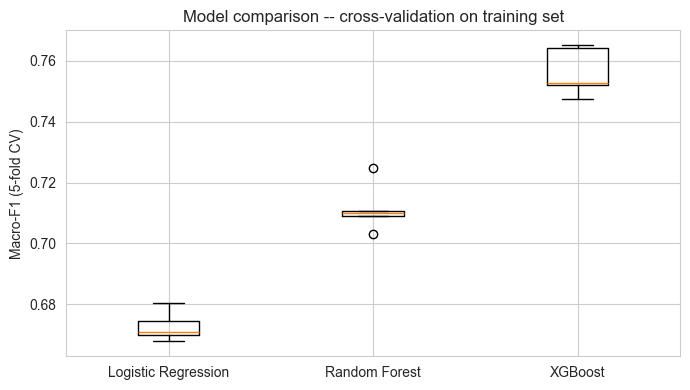

Selected model: XGBoost  (mean CV Macro-F1 = 0.7563)


In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(cv_results.values(), labels=cv_results.keys())
ax.set_ylabel('Macro-F1 (5-fold CV)')
ax.set_title('Model comparison -- cross-validation on training set')
plt.tight_layout()
plt.savefig(OUT_DIR / 'cv_comparison.png', dpi=110)
plt.show()

best_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f'Selected model: {best_name}  (mean CV Macro-F1 = {cv_results[best_name].mean():.4f})')


## 4. Refit the winner on the full training set, evaluate once on test

This is the only time the test set is touched.

XGBoost -- held-out test set
              precision    recall  f1-score   support

           1       0.90      0.41      0.56      1131
           2       0.85      0.99      0.92      4939
           3       0.96      0.62      0.75       451

    accuracy                           0.86      6521
   macro avg       0.90      0.67      0.74      6521
weighted avg       0.87      0.86      0.84      6521

Test Macro-F1: 0.7426


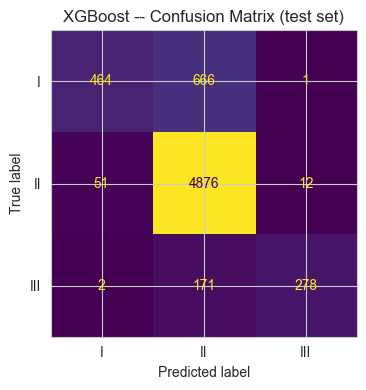

In [6]:
best_model = candidates[best_name]
best_model.fit(X_train_t, y_train)

y_pred = best_model.predict(X_test_t)
test_macro_f1 = f1_score(y_test, y_pred, average='macro')
report = classification_report(y_test, y_pred, output_dict=True)
report_str = classification_report(y_test, y_pred)

print(f'{best_name} -- held-out test set')
print(report_str)
print(f'Test Macro-F1: {test_macro_f1:.4f}')

cm = confusion_matrix(y_test, y_pred, labels=CLASS_LABELS)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False)
ax.set_title(f'{best_name} -- Confusion Matrix (test set)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrix_final.png', dpi=110)
plt.show()


## 5. Quick explainability — feature importance

Not a full SHAP analysis, but a fast, honest first pass: for tree models we can read importances
directly; this alone is worth having on a presentation slide for "Model Performance and Evaluation.SHAP is a natural next step if time allows.

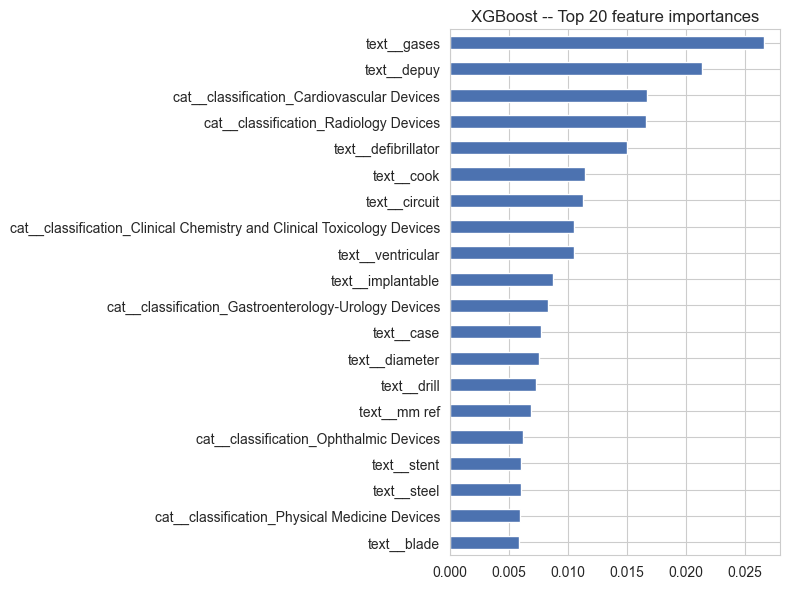

In [7]:
feature_names = preprocessor.get_feature_names_out()

underlying = best_model.base_estimator_ if hasattr(best_model, 'base_estimator_') else best_model

if hasattr(underlying, 'feature_importances_'):
    importances = pd.Series(underlying.feature_importances_, index=feature_names)
    top20 = importances.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(8, 6))
    top20.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
    ax.set_title(f'{best_name} -- Top 20 feature importances')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'feature_importance.png', dpi=110)
    plt.show()
else:
    print(f'{best_name} has no native feature_importances_ (e.g. Logistic Regression) -- '
          f'use coefficients or a permutation-importance pass instead if this model is selected.')


## 6. Save artifacts -- both pipeline and model, consistent naming

In [8]:
joblib.dump(preprocessor, OUT_DIR / 'pipeline.pkl')
joblib.dump(preprocessor, BACKEND_ML_DIR / 'pipeline.pkl')

joblib.dump(best_model, OUT_DIR / 'model.pkl')
joblib.dump(best_model, BACKEND_ML_DIR / 'model.pkl')

model_size_mb = (BACKEND_ML_DIR / 'model.pkl').stat().st_size / 1e6
print(f'pipeline.pkl and model.pkl saved to outputs/ and backend/app/ml/')
print(f'model.pkl size: {model_size_mb:.1f} MB')


pipeline.pkl and model.pkl saved to outputs/ and backend/app/ml/
model.pkl size: 1.2 MB


## 7. Save metrics + model version metadata

In [9]:
per_class_metrics = {
    str(cls): {
        'precision': round(report[str(cls)]['precision'], 4),
        'recall': round(report[str(cls)]['recall'], 4),
        'f1': round(report[str(cls)]['f1-score'], 4),
    }
    for cls in CLASS_LABELS
}

metrics_payload = {
    'selected_model': best_name,
    'selection_method': '5-fold stratified CV on training set (macro-F1)',
    'cv_macro_f1_mean': round(float(cv_results[best_name].mean()), 4),
    'cv_macro_f1_std': round(float(cv_results[best_name].std()), 4),
    'test_macro_f1': round(float(test_macro_f1), 4),
    'test_per_class': per_class_metrics,
    'cv_all_candidates': {
        name: {'mean': round(float(s.mean()), 4), 'std': round(float(s.std()), 4)}
        for name, s in cv_results.items()
    },
    'model_size_mb': round(model_size_mb, 1),
    'class_labels': CLASS_LABELS,
    'class_names': CLASS_NAMES,
}

with open(OUT_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_payload, f, indent=2)

print(json.dumps(metrics_payload, indent=2))


{
  "selected_model": "XGBoost",
  "selection_method": "5-fold stratified CV on training set (macro-F1)",
  "cv_macro_f1_mean": 0.7563,
  "cv_macro_f1_std": 0.0071,
  "test_macro_f1": 0.7426,
  "test_per_class": {
    "1": {
      "precision": 0.8975,
      "recall": 0.4103,
      "f1": 0.5631
    },
    "2": {
      "precision": 0.8535,
      "recall": 0.9872,
      "f1": 0.9155
    },
    "3": {
      "precision": 0.9553,
      "recall": 0.6164,
      "f1": 0.7493
    }
  },
  "cv_all_candidates": {
    "Logistic Regression": {
      "mean": 0.6727,
      "std": 0.0044
    },
    "Random Forest": {
      "mean": 0.7115,
      "std": 0.0072
    },
    "XGBoost": {
      "mean": 0.7563,
      "std": 0.0071
    }
  },
  "model_size_mb": 1.2,
  "class_labels": [
    1,
    2,
    3
  ],
  "class_names": [
    "I",
    "II",
    "III"
  ]
}


## Summary

| Artifact | Location | Used by |
|----------|----------|---------|
| `model.pkl` | `backend/app/ml/` | FastAPI `prediction_service.py` |
| `pipeline.pkl` | `backend/app/ml/` | FastAPI `prediction_service.py` |
| `metrics.json` | `outputs/` | FastAPI `metrics_service.py` / `model_versions` table |
| `cv_comparison.png`, `confusion_matrix_final.png`, `feature_importance.png` | `outputs/` | Presentation |

**Inference flow** (matches `backend/app/services/prediction_service.py`):
```
raw input dict
  -> pipeline.pkl.transform()
  -> model.pkl.predict_proba()   # columns ordered by model.classes_ == [1, 2, 3]
  -> { predicted_class, confidence, probabilities: {"I": .., "II": .., "III": ..} }
```

**Caveat to state explicitly in the presentation**: `test_macro_f1` above is a single held-out
measurement, not a cross-validated estimate -- the CV numbers (`cv_macro_f1_mean` /
`cv_macro_f1_std`) are the more defensible generalization estimate to quote if asked "how
confident are you in this number."
